In [ ]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# Configuración de stilo global para las gráficas
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

In [ ]:
def avg_power_to_pulse_power(avg_power, frecuency, t_pulse, area):

  # Energia por pulso
  E_pulse = avg_power / frecuency

  # Potencia por pico
  P_pulse = E_pulse / t_pulse

  # Densidad de Potencia pico
  return P_pulse / area

In [ ]:
def delta1_calc(q_m, t_pulse, alpha, k, avg_power):
  # 2. Arreglo de tiempo de 0 a 100 fs
  t1_fs = np.linspace(0, t_pulse, 500)
  t1_s_arr = t1_fs * 1e-15

  # 3. Ecuación de sólido semi-infinito
  T1 = 2 * q_m * np.sqrt((alpha * t1_s_arr) / np.pi) / k

  fig1, ax1 = plt.subplots(figsize=(8, 5))
  ax1.plot(t1_fs, T1, color='#D95319', linewidth=2, label='10.8 $\mu$m pixel')
  ax1.set_xlabel('Time [fs]')
  ax1.set_ylabel('Temperature [$^\circ$C]')
  ax1.set_title(f'Delta 1: Surface to Bulk ({t_pulse} fs, {avg_power} mW)')
  ax1.set_xlim(0, t_pulse)
  ax1.grid(True, linestyle='--', alpha=0.6)
  ax1.legend(loc='upper left', frameon=True, edgecolor='black')
  plt.plot()

  return T1[-1]

In [ ]:
def delta2_calc(t_pulse_us, period_us, Tf, tau, frecuencia_KHz):
  t2_lista = []
  T2_lista = []
  temp_actual = 0.0

  # variables de bucle
  cicle_number = 0
  not_treshold = True
  prev_peak_temp = 0
  tolerance = 0.0000001   # steady-state condition tolerance

  while not_treshold and cicle_number < 10 :
    t_inicio = cicle_number * period_us
    t_pico = t_inicio + t_pulse_us
    t_fin = t_inicio + period_us

    # Pulso instantáneo
    t_cal = np.linspace(t_inicio, t_pico, 100)
    T_cal = Tf + (temp_actual - Tf) * np.exp(-(t_cal - t_inicio) / tau)
    temp_pico = T_cal[-1]

    # Enfriamiento masivo
    t_enf = np.linspace(t_pico, t_fin, 500)
    T_enf = 0 + (temp_pico - 0) * np.exp(-(t_enf - t_pico) / tau)
    temp_actual = T_enf[-1]               # Termina virtualmente en 0.0

    # Bucle info
    #print(f"Ciclo:{cicle_number+1}")
    #print(f"Temperatura pico:{temp_pico}")
    #print(f"Temperatura final:{temp_actual}")

    # concdición del ciclo

    if abs(prev_peak_temp - temp_pico) < tolerance:
        not_treshold = False
    else:
        prev_peak_temp = temp_pico
        cicle_number += 1

    # Concatenar a las listas principales (omitiendo el primer punto del enfriamiento para no duplicar)
    t2_lista.extend(t_cal); T2_lista.extend(T_cal)
    t2_lista.extend(t_enf[1:]); T2_lista.extend(T_enf[1:])

  t2 = np.array(t2_lista) / 1000 # Convertir Eje X a Milisegundos para la gráfica
  T2 = np.array(T2_lista)

  fig2, ax2 = plt.subplots(figsize=(8, 5))
  ax2.plot(t2, T2, color='#D95319', linewidth=1.5, label='10.8 $\mu$m pixel')
  ax2.set_xlabel('Time [ms]')
  ax2.set_ylabel('Temperature [$^\circ$C]')
  ax2.set_title(f'Delta 2: Bulk to Silicon ({t_pulse_us*1e9:.1f} fs, {frecuencia_KHz} kHz Repetition)')
  ax2.set_xlim(0, (cicle_number+1) * period_us * 1e-6 * 1000)
  ax2.grid(True, linestyle='--', alpha=0.6)
  ax2.legend(loc='upper right', frameon=True, edgecolor='black')
  plt.plot()

  return temp_pico

In [ ]:
def delta3_calc(avg_power, alpha_DMD):

  Q_absorbed_opt = avg_power * alpha_DMD

  Q_electrical = 1.8 # W
  R_silicon_ceramic = 0.5 # C/W
  return (Q_electrical + Q_absorbed_opt) * R_silicon_ceramic

In [ ]:
# ---------------------------------------------------------------------
# Cálculo del cambio en la temperatura del DMD débido a Múltiples Pulsos
# ---------------------------------------------------------------------

def DMD_Temp_change(t_pulse, frecuencia_KHz, avg_power_mW, dmd_length_mm):

  frecuencia_Hz = frecuencia_KHz * 1e3
  avg_power = avg_power_mW * 1e-3

  t_pulse_s = t_pulse * 1e-15     # en segundos
  t_pulse_us = t_pulse_s * 1e6    # en microsegundos

  period_s = 1 / frecuencia_Hz
  period_us = period_s * 1e6

  # Parámetros del DMD (Datashet)
  alpha = 6.4667e-5 # m^2/s (Difusividad térmica)
  k = 160 # W/m-C (Conductividad térmica)
  tau = 32.27  # Constante de tiempo térmica en microsegundos (us)
  area_pixel_cm2 = (10.8e-4)**2

  # Parámetros del DMD (Tablas)
  R_bulk_silicon = 3.39e5       # Resistencia térmica Espejo-Silicio
  MR = 0.94                     # Reflectividad
  FF_on = 0.931                 # Factor de llenado en estado ON

  # Densidad de potencia pico
  area_cm2 = (dmd_length_mm*0.1)**2
  potencia_pico_W_cm2 = avg_power_to_pulse_power(avg_power, frecuencia_Hz, t_pulse_s, area_cm2)
  potencia_pico_W_m2 = potencia_pico_W_cm2 * 10000


  # ---------------------------------------------------------------------
  # CÁLCULO Y GRÁFICA: DELTA 1 (Superficie a Volumen)
  # ---------------------------------------------------------------------

  # 1. Calor absorbido (q)
  q_m = potencia_pico_W_m2 * (1 - MR)

  delta1 = delta1_calc(q_m, t_pulse, alpha, k, avg_power_mW)

  # ---------------------------------------------------------------------
  # CÁLCULO Y GRÁFICA: DELTA 2 (Volumen a Silicio)
  # ---------------------------------------------------------------------

  Q_mirror = (potencia_pico_W_cm2 * area_pixel_cm2) * (FF_on * (1 - MR))
  Tf = Q_mirror * R_bulk_silicon # Temperatura en estado estacionario ideal

  delta2 = delta2_calc(t_pulse_us, period_us, Tf, tau, frecuencia_KHz)

  # ---------------------------------------------------------------------
  # CÁLCULO: DELTA 3 (Silicio a Cerámica)
  # ---------------------------------------------------------------------

  alpha_DMD = 0.33
  delta3 = delta3_calc(avg_power, alpha_DMD)


  print(f"Densidad de Potencia Pico Calculada: {potencia_pico_W_cm2/1e6:,.0f} MW/cm^2")
  print(f"\n-> Delta 1 Máximo (Superficie): {delta1:.4f} °C")
  print(f"\n-> Delta 2 Máximo (Volumen):    {delta2:.5f} °C")
  print(f"\n-> Delta 3 (Silicio):           {delta3:.4f} °C")
  print(f"\nGradiente total de temperatura: {(delta1 + delta2 + delta3):.2f} [°C]\n")

Densidad de Potencia Pico Calculada: 25 kW/cm^2

-> Delta 1 Máximo (Superficie): 0.8439 °C

-> Delta 2 Máximo (Volumen):    16.71569 °C

-> Delta 3 (Silicio):           1.9231 °C

Gradiente total de temperatura: 19.48 [°C]



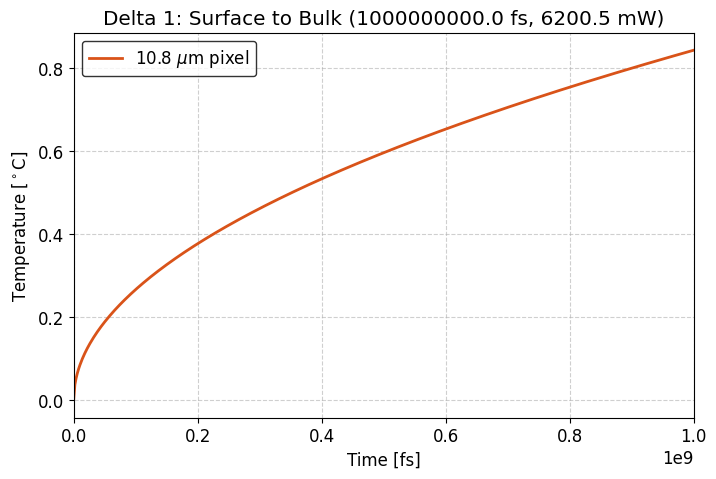

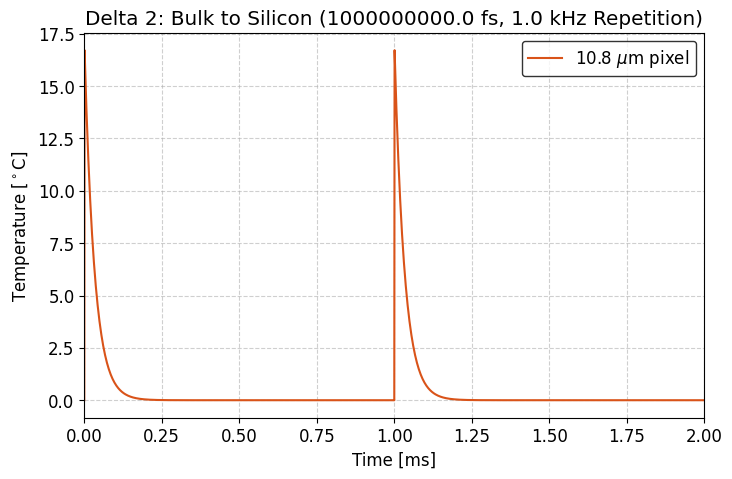

In [ ]:
# Ejemplo 1 del articulo
DMD_Temp_change(1.0e9, 1.0, 6200.5, 5.0)

Densidad de Potencia Pico Calculada: 250 MW/cm^2

-> Delta 1 Máximo (Superficie): 26.9010 °C

-> Delta 2 Máximo (Volumen):    1.79197 °C

-> Delta 3 (Silicio):           1.9312 °C

Gradiente total de temperatura: 30.62 [°C]



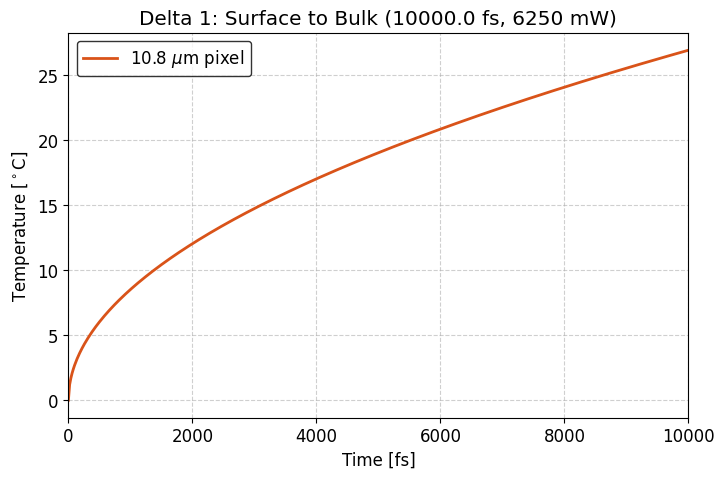

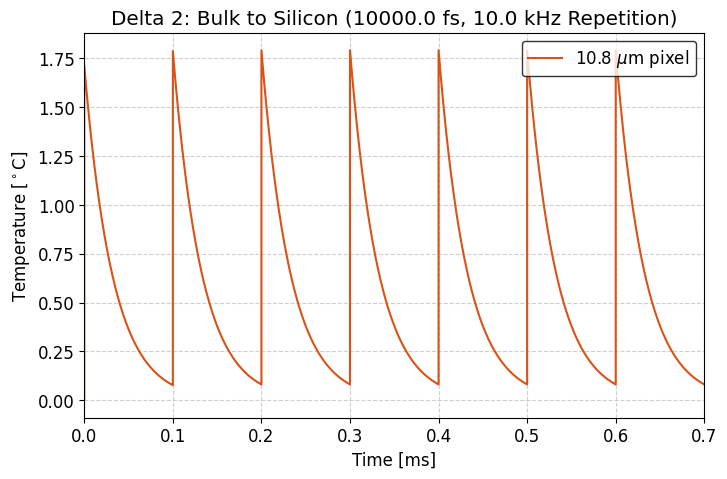

In [ ]:
# Ejemplo 2 del articulo
DMD_Temp_change(10e3, 10.0, 6250, 5.0)

Densidad de Potencia Pico Calculada: 250 MW/cm^2

-> Delta 1 Máximo (Superficie): 2.6901 °C

-> Delta 2 Máximo (Volumen):    0.01792 °C

-> Delta 3 (Silicio):           0.9103 °C

Gradiente total de temperatura: 3.62 [°C]



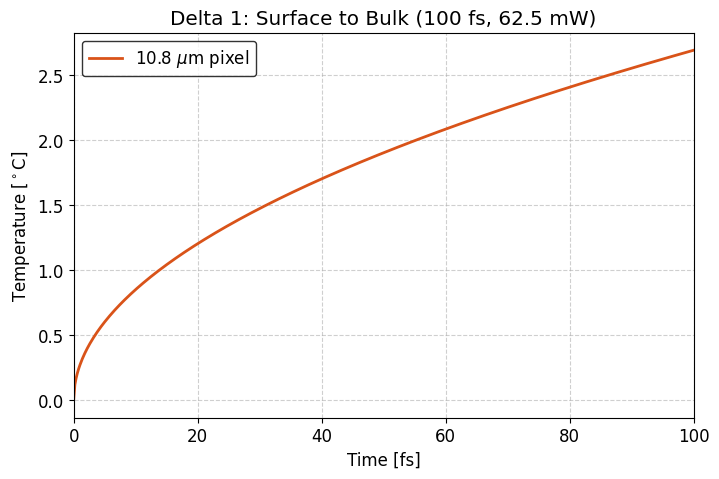

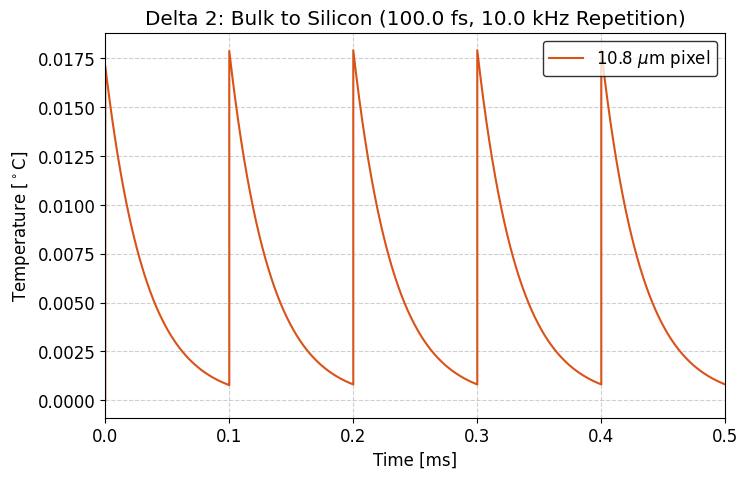

In [ ]:
# Ejemplo 3 del articulo
DMD_Temp_change(100, 10.0, 62.5, 5.0)

Densidad de Potencia Pico Calculada: 16,000 MW/cm^2

-> Delta 1 Máximo (Superficie): 172.1661 °C

-> Delta 2 Máximo (Volumen):    1.09514 °C

-> Delta 3 (Silicio):           0.9660 °C

Gradiente total de temperatura: 174.23 [°C]



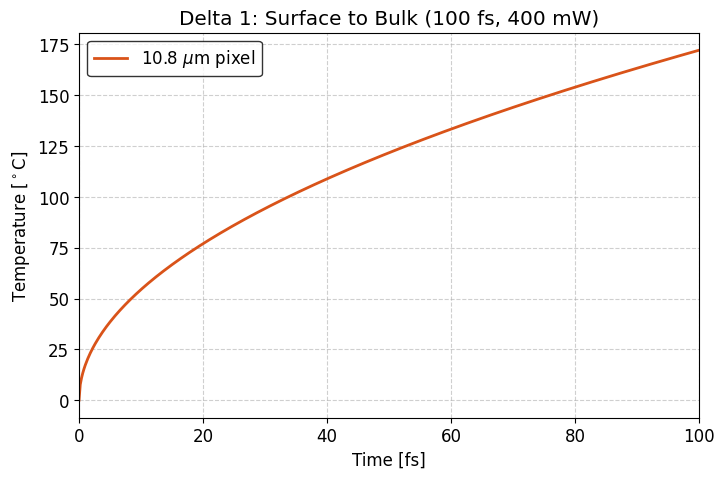

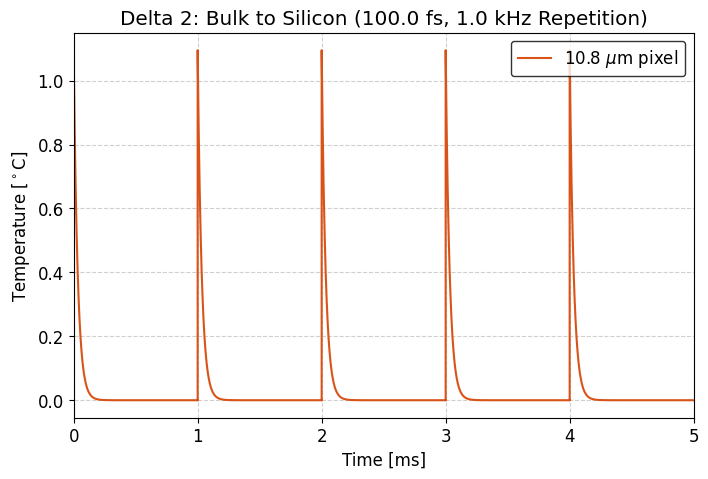

In [ ]:
DMD_Temp_change(100, 1.0, 400, 5.0)